<a href="https://colab.research.google.com/github/Arfa-Tariq/learning-ai-engineering/blob/main/projects/06-Function-Calling-%26-Data_Extraction/01_FunctionCalling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## writing a local python tool

In [1]:
from matplotlib import pyplot as plt

In [2]:
def plot_some_points(x: list, y: list):
  """plots some points"""
  plt.plot(x, y)
  plt.show()

In [3]:
User_query = "Hey can you plot y=10x where x=1,2,3 for me?"

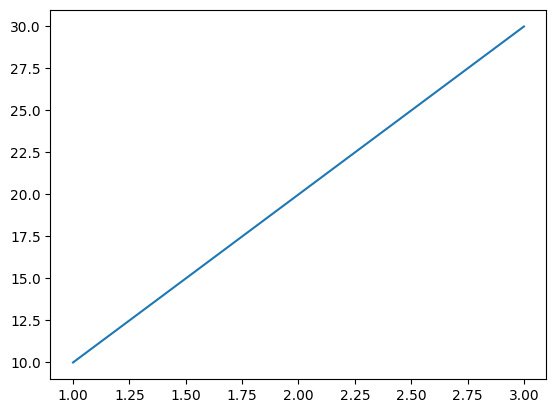

In [4]:
plot_some_points(x=[1,2,3],y=[10,20,30])

## Now we use the LLM to call the function

In [5]:
prompt= f'''
Function:
def plot_some_points(x: list, y: list):
  """plots some points"""
  plt.plot(x, y)
  plt.show()

User Query: {User_query}<human_end>
'''


In [6]:
!pip install -q groq

from groq import Groq
from google.colab import userdata
import tiktoken

GROQ_API_KEY = userdata.get('groq_key')
client = Groq(api_key=GROQ_API_KEY)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.6 MB/s eta 0:00:00


In [24]:
def get_completion(prompt, model="llama-3.3-70b-versatile"):
  messages = [{'role':'system','content': "You are being used as a tool calling agent, just respond with the function call ONLY"},
              {"role": "user", "content": prompt}]
  response = client.chat.completions.create(
    model=model,
    messages=messages,
    temperature=1,)
  return response.choices[0].message.content

In [22]:
function_call = get_completion(prompt)

In [23]:
print (function_call)

plot_some_points(x=[1, 2, 3], y=[10, 20, 30])


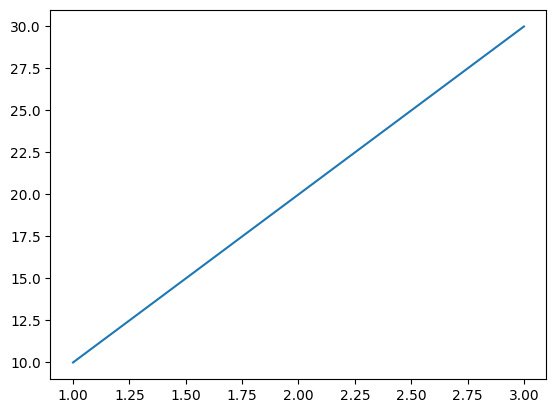

In [26]:
exec(function_call)